# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AbdulWasay65/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

### Research Question

Can a machine-learning model use page-level Google Search Console performance signals from March 2026 to prioritize pages that subsequently achieve an improvement of at least two average-position places in April 2026?

### Decision Supported

The model is intended to support a content-prioritization decision: which pages should be reviewed first by a human SEO or content team.

The output is a prioritization signal rather than a guarantee that a page will improve. The goal is to help a team focus limited review and optimization time on pages with stronger historical signals of subsequent improvement.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This research uses the FlyRank internship warehouse dataset, a large page-level search-performance dataset containing Google Search Console and related SEO observations.

The modeling analysis uses the warehouse's daily content-performance data, aggregated at the client and content-page level.

### Date Window

March 2026 is used as the decision-time observation window. April 2026 is used as the subsequent outcome window.

March provides the features available when making the prioritization decision:

* impressions
* clicks
* average Google Search position

April provides the observed outcome used to define the target.

### Inclusion and Exclusion

Pages were included when they had usable Google Search Console data in both March and April 2026 and had non-null average-position values for both periods.

Pages without usable April outcome data were excluded because their subsequent improvement could not be measured reliably.

Client-identifying information, private URLs, search queries, and other potentially sensitive information are not included in the public-facing research artifact.

The results should therefore be interpreted as directional evidence from the analyzed subset rather than as a universal estimate for all websites or search results.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Modeling Approach

The analysis uses a Random Forest classifier to estimate whether a page subsequently achieves an improvement of at least two Google Search average-position places.

### Features

The model uses three March 2026 decision-time features:

1. March impressions
2. March clicks
3. March average position

These features represent information available before the April outcome.

### Target Definition

The target is defined as:

`1` if April average position is at least 2 positions better than March average position.

Formally:

`April average position <= March average position - 2`

Otherwise, the target is `0`.

Because lower Google Search average-position values represent better positions, this definition treats a decrease of at least two positions as an improvement.

### Baseline

The model is compared with the Week-4 baseline action score using Average Precision (AP).

The baseline AP was **0.2086**.

The Random Forest model achieved an AP of **0.3685**, an observed improvement of **0.1599 AP points** over the baseline.

### Validation Design

The modeling data uses a grouped train/test split based on `client_hash_id`, with 80% of groups used for training and 20% for testing.

This prevents pages belonging to the same client from being arbitrarily distributed across both sets.

The split uses `random_state=42` for reproducibility.

The validation audit also produced a grouped ROC AUC of **0.7947**.

### Leakage Checks

The target is calculated from April 2026, while the model features come from March 2026.

Therefore, April outcome information is not used as a model feature.

The decision-time features are restricted to information available before the measured outcome period.

### Key Assumption

The model estimates historical association with subsequent improvement. It does not establish that changing one of the input features causes ranking improvement.


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

### Results

On the same modeling task, the Random Forest produced a higher Average Precision score than the Week-4 baseline.

| Method               | Average Precision |
| -------------------- | ----------------: |
| Week-4 baseline      |            0.2086 |
| Random Forest        |            0.3685 |
| Observed improvement |           +0.1599 |

The Random Forest therefore provided stronger ranking performance than the baseline on the evaluated task.

The result should be interpreted as evidence that the three selected March performance features contain useful predictive signal for prioritization. It does not demonstrate causation or guarantee that a recommended page will improve after intervention.

The model's feature importance was concentrated in March average position, which accounted for approximately 80.8% of the model's feature importance, followed by impressions at approximately 12.5% and clicks at approximately 6.8%.

The validation audit found a grouped ROC AUC of 0.7947. Error analysis also showed that the model generated many false positives, reinforcing that the output should be reviewed by humans rather than treated as an automatic action decision.


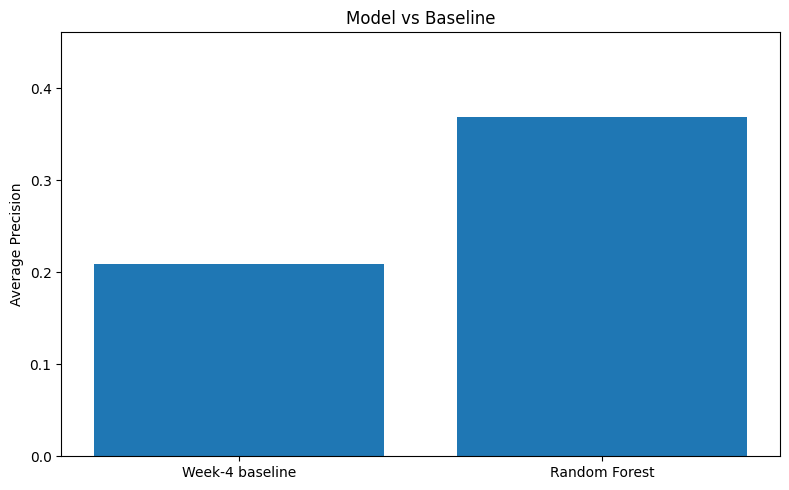

In [2]:
import matplotlib.pyplot as plt

methods = ["Week-4 baseline", "Random Forest"]
scores = [0.2086, 0.3685]

plt.figure(figsize=(8, 5))
plt.bar(methods, scores)
plt.ylabel("Average Precision")
plt.title("Model vs Baseline")
plt.ylim(0, max(scores) * 1.25)
plt.tight_layout()
plt.show()

## 5. Limitations

*What this work cannot claim.*

### Limitations and Honest Framing

This analysis has several important limitations.

First, the model is based on a limited set of three page-level performance features. It does not directly observe content quality, search intent, topical relevance, backlinks, technical SEO conditions, SERP competition, or the details of changes made to a page.

Second, the analysis covers a March-to-April 2026 observation window. The measured relationships may not remain stable across different time periods, websites, industries, or search environments.

Third, the target represents an observed subsequent improvement in average position. The model does not prove that any specific action caused that improvement.

Fourth, the Random Forest can assign the same score to pages with identical feature values. This means that identical scores should not be interpreted as precise differences in expected outcomes.

Fifth, the model produced a substantial number of false positives in the evaluated data. This makes human review an essential part of the workflow.

Finally, missing or unreliable Google Search Console data can affect both modeling and interpretation.

Accordingly, the model should be described as a directional decision-support tool for prioritization, not as a causal SEO optimizer or a guarantee of ranking improvement.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

### Ranked Recommendations

The model output should be used to create a ranked review queue rather than to automatically change content.

#### 1. Review highest-scoring pages first

Pages with higher model scores should receive earlier human review because the model assigns them stronger historical likelihood of the defined improvement outcome.

#### 2. Verify search intent and relevance

Before making any change, reviewers should confirm that the page satisfies the intended search need and remains relevant to the queries and topic it serves.

#### 3. Check for outdated or incomplete content

Reviewers should identify obsolete information, missing explanations, weak specificity, or important gaps that could reduce usefulness.

#### 4. Review titles and headings

Check whether the title and major headings accurately communicate the page's subject and align with the intended search intent.

#### 5. Examine internal linking and technical conditions

Review internal links and relevant indexing or technical issues before attributing performance to content quality alone.

#### 6. Compare the current search results

Review competing pages and the current search-result environment before recommending substantial content changes.

#### 7. Record the human decision

Each recommended action should receive a human decision such as APPROVE, MODIFY, REJECT, or HOLD, together with the reason.

### No-Go Rules

The model score must not be used by itself to:

* automatically rewrite or publish content
* automatically delete pages
* claim that an SEO change caused ranking improvement
* treat low scores as proof that content is poor
* fabricate facts, statistics, sources, or quotations
* override expert review without evidence
* make irreversible publishing decisions without human approval

The final recommendation is therefore a human-reviewed action queue, not an automated content-production system.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

### Paper Artifacts

The research paper should embed or link to the following artifacts generated during the analysis:

1. **Model vs baseline chart** — comparison of Average Precision for the Week-4 baseline and Random Forest.
2. **Score-band monitoring chart** — historical observed improvement rate across model-score bands.
3. **Ranked action queue** — the model-generated prioritization output for human review.
4. **Paper-ready metrics** — machine-readable summary of the model, target, features, queue statistics, and monitoring information.

The corresponding project artifacts are stored under:

* `work/outputs/`
* `work/figures/`

The primary ML-10 action queue is:

`work/outputs/ml10_ranked_action_queue.csv`

The paper-ready metrics are:

`work/outputs/ml10_playbook_metrics.json`

The score-band monitoring figure is:

`work/figures/ml10_score_band_monitoring.png`


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
